# Aufgabenblatt 8

<p style="background-color:#f6f6f6;border-left:5px solid red;padding:0.6em;box-sizing:border-box;">
<strong>Lernziele:</strong><br/>
    In dieser Übung beschäftigen wir uns mit weiteren charackteristischen Grössen von stochastischen Signalen.
</p>

<p style="background-color:#f6f6f6;border-left:5px solid blue;padding:0.6em;box-sizing:border-box;">
<strong>Wichtigste neue Funktionen für diese Übung:</strong><br/>
    Dies sind die wichtigsten Funktionen, die Sie während dieser Übung benötigen:<br>
    Die jeweilige Syntax beschreibt eine examplarische Verwendung. Der Funktionsname ist jeweils ein Link zur offiziellen Dokumentation, welche alle Argumente der Funktion darlegt und ihre Funktionalität beschreibt. <br>
    <b>Funktionen zur statistischen Analyse: </b><br>
    <a href="https://numpy.org/doc/stable/reference/generated/numpy.arange.html">numpy.arange(...)</a> Gibt ein Array mit gleichmässig verteilten Werten zurück.<br>
    <a href="https://numpy.org/doc/stable/reference/generated/numpy.where.html">numpy.where(...)</a> Diese Funktion gibt alle Indices eines Arrays zurück, welche eine definierte Bedingung erfüllen.<br>
    <a href="https://numpy.org/doc/stable/reference/generated/numpy.histogram.html">numpy.histogram(...)</a> Berechnet das Histogramm der übergebenen Daten. Dabei hält es sich an die übergebenen Ränder der Buckets.<br>
    <b>Funktionen zum Plotten: </b><br>
    <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axvline.html"> axis.axvline(...)</a> Fügt eine vertikale Linie dem Plot hinzu.<br>
    <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axhline.html"> axis.axhline(...)</a> Fügt eine horizontale Linie dem Plot hinzu.<br>
</p>

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Aufgabe 1 Wahrscheinlichkeitsmassenfunktion

Wie Sie aus der Vorlesung wissen, gibt die Wahrscheinlichkeitsmassenfunktion (probability mass function, kurz PMF) die Wahrscheinlichkeit an, mit der ein bestimmter Wert z.B. in einem Datensatz vorkommt. Sie ist für diskrete Wahrscheinlichkeitsverteilungen das Analogon zur Wahrscheinlichkeitsdichtefunktion.

### a)

Schreiben Sie eine Funktion, die die Wahrscheinlichkeitsmassenfunktion für einen Datensatz berechnet. Die Diskretisierung der Daten wird durch die Auflösung der Messung oder allfälliges späteres Binning gegeben sein. Die Funktion sollte also die Daten sowie die Auflösung der Daten als Argument nehmen und die möglichen Werte mit den dazugehörigen Wahrscheinlichkeiten zurückgeben.

Sie können dazu die `np.histogramm` Funktion benutzen. Beachten Sie dabei, dass Sie die Bins richtig definieren. Falls `bins = [1, 2, 3]` dann ist das erste Bin durch die Grenzen `[1, 2)` und das zweite durch `[2, 3)` gegeben.


In [6]:
def PMF(data, resolution):

    bin_centers = np.arange(np.min(data), np.max(data) + resolution / 1000, resolution)
    bin_edges = np.linspace(bin_centers[0] - resolution / 2, bin_centers[-1] + resolution / 2, len(bin_centers) + 1)

    hist, _ = np.histogram(data, bin_edges)

    px = hist / np.sum(hist)

    return bin_centers, px

### b)

In der Datei `Voltages.txt` finden Sie zwei Datensätze mit Spannungen mit einer Auflösung von 10mV als Funktion der Zeit. Laden Sie die Datensätze, berechnen Sie jeweils die PMF und stellen Sie sie graphisch dar. Überprüfen Sie dabei Ihre Funktion, indem Sie die Summe über alle Wahrscheinlichkeiten berechnen. Welchen Wert sollten Sie erhalten?

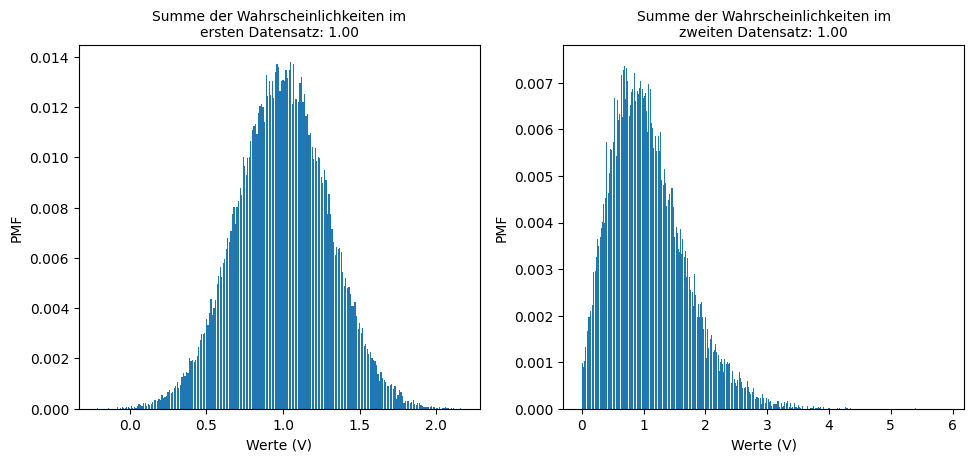

In [10]:
data = np.loadtxt('Voltages.txt', skiprows=1)
time = data[0, :]
v1 = data[1, :]
v2 = data[2, :]
resolution = 1e-2

cm = 1 / 2.54
fig = plt.figure(figsize=(25 * cm, 12 * cm))

ax = fig.add_subplot(1, 2, 1)
x, px = PMF(v1, resolution)
ax.bar(x, px, resolution*0.8)
ax.set_xlabel('Werte (V)')
ax.set_ylabel('PMF')
ax.set_title('Summe der Wahrscheinlichkeiten im\nersten Datensatz: {:.2f}'.format(np.sum(px)), size=10)

ax = fig.add_subplot(1, 2, 2)
x, px = PMF(v2, resolution)
ax.bar(x, px, resolution*0.8)
ax.set_xlabel('Werte (V)')
ax.set_ylabel('PMF')
ax.set_title('Summe der Wahrscheinlichkeiten im\nzweiten Datensatz: {:.2f}'.format(np.sum(px)), size=10)

fig.tight_layout()


### c)

Sie haben in der Vorlesung die Begriffe Mode, Median und Mittelwert kennengelernt. Schreiben Sie eine Funktion, die ein Set an Daten und deren Auflösung als Argument nimmt und die Mode und den Median der Daten zurückgibt. Sie können zur Hilfe auch geeignete Numpy Funktionen verwenden.

In [14]:
def mode(data, resolution):
    x, px = PMF(data, resolution)
    return x[np.argmax(px)]

def mode_manual(data, resolutio):
    x, px = PMF(data, resolution)

    max_x = 0
    max_val = px[0]
    for i, val in enumerate(px):
        if val > max_val:
            max_val = val
            max_x = x[i]
    
    return max_x

def median(data, resolution):
    x, px = PMF(data, resolution)
    curr_sum = 0
    for i in range(len(x)):
        curr_sum += px[i]
        if curr_sum >= 0.5:
            break
    return x[i]

def mediansort(data):
    data_sorted = np.sort(data)
    if len(data) % 2 != 0:
        median = data_sorted[len(data) // 2]
    else:
        median = (data_sorted[len(data)//2] + data_sorted[len(data)//2 - 1]) / 2
    return median



### d)

Plotten Sie nun die Mode, den Median und den Mittelwert der Datensätze in die PMF. Was für Unterschiede werden deutlich?

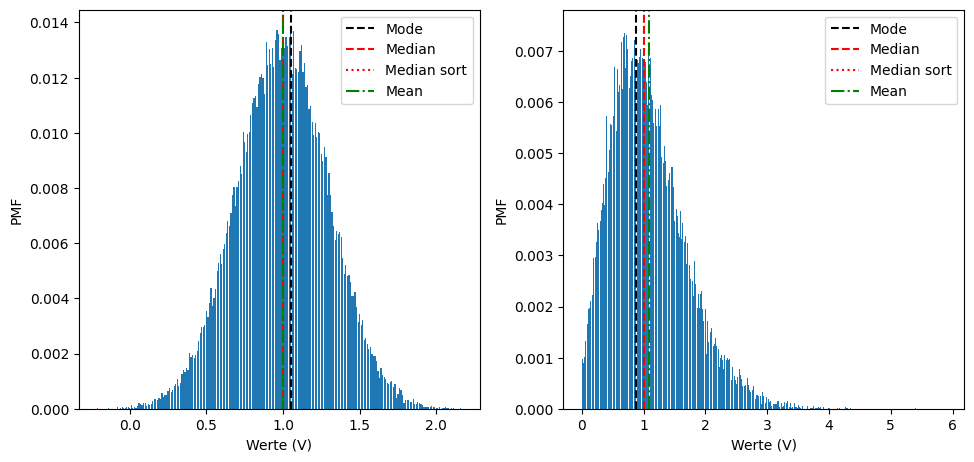

In [17]:
fig = plt.figure(figsize=(25*cm, 12*cm))

x, px = PMF(v1, resolution)

ax = fig.add_subplot(1,2,1)
ax.bar(x, px, resolution*0.8)

ax.axvline(mode(v1, resolution), color='k', linestyle='--', label='Mode')
ax.axvline(median(v1, resolution), color='r', linestyle='--', label='Median')
ax.axvline(mediansort(v1), color='r', linestyle=':', label='Median sort')
ax.axvline(np.mean(v1), color='g', linestyle='-.', label='Mean')

ax.set_xlabel('Werte (V)')
ax.set_ylabel('PMF')
#ax.set_xlim(0.975,1.02)
ax.legend()


x, px = PMF(v2, resolution)

ax = fig.add_subplot(1,2,2)
ax.bar(x, px, resolution*0.8)

ax.axvline(mode(v2, resolution), color='k', linestyle='--', label='Mode')
ax.axvline(median(v2, resolution), color='r', linestyle='--', label='Median')
ax.axvline(mediansort(v2), color='r', linestyle=':', label='Median sort')
ax.axvline(np.mean(v2), color='g', linestyle='-.', label='Mean')

ax.set_xlabel('Werte (V)')
ax.set_ylabel('PMF')
#ax.set_xlim(0.975,1.02)
ax.legend()

fig.tight_layout()

### e)

Eine wichtige Kenngrösse einer Verteilung ist deren Breite, und eine häufig verwendete Definition dafür ist die Breite auf halber Höhe (full width at half maximum oder kurz FWHM). Schreiben Sie eine Funktion, die die FWHM für eine Verteilung berechnet, die ein einzelnes Maximum aufweist. Für Datensätze mit starkem Rauschen kann das Finden des halben Wertes komplizierter werden. Sie haben bereits Methoden gesehen, wie man Daten glätten kann, nehmen Sie also für diese Aufgabe an, dass das Rauschen der Daten kleiner ist als deren Auflösung.

In [20]:
def FWHM1(x, y):
    # Definieren eines Arrays, in das alle Indizes gespeichtert werden, bei denen y>=y/2
    larger_idx = np.array([],dtype=int)
    for i in range(len(y)):
        if y[i] >= np.max(y)/2:
            larger_idx = np.append(larger_idx, i)
            
    # Die FWHM ist dann x beim letzten dieser Indizes minus x beim ersten
    x0 = x[larger_idx[0]]
    x1 = x[larger_idx[-1]]
    return abs(x1 - x0)


def FWHM2(x, y):
    # np.where findet alle Werte, die die gegebene Bedingung erfüllen, und gibt deren Indizes aus.
    # Wir wählen also den ersten und letzten Wert, der grösser ist als die Hälfte des Maximums,
    # und geben deren Abstand wieder. 
    x0 = x[np.where(px >= np.max(y)/2)[0][0]]
    x1 = x[np.where(px >= np.max(y)/2)[0][-1]]
    return abs(x1 - x0)

### f)

Berechnen Sie die FWHM der PMF der Daten aus den beiden Datensätzen. Für normalverteilte Daten kann die FWHM auch analytisch berechnet werden. Dabei gilt, dass $\mathrm{FWHM} = 2\sigma\sqrt{2\log{2}}$, wobei $\sigma$ die Wurzel der Varianz ist. Vergleichen Sie das Resultat Ihrer Funktion mit der FWHM, die Sie aus der Varianz berechnen. Können Sie die Abweichungen erklären? (Der symmetrische Datensatz ist Normalverteilt.)

Erster Datensatz:
FWHM: 0.660000
sigma: 0.299801 -> FWHM = 0.705977
Zweiter Datensatz:
FWHM: 1.340000
sigma: 0.611588 -> FWHM = 1.440180


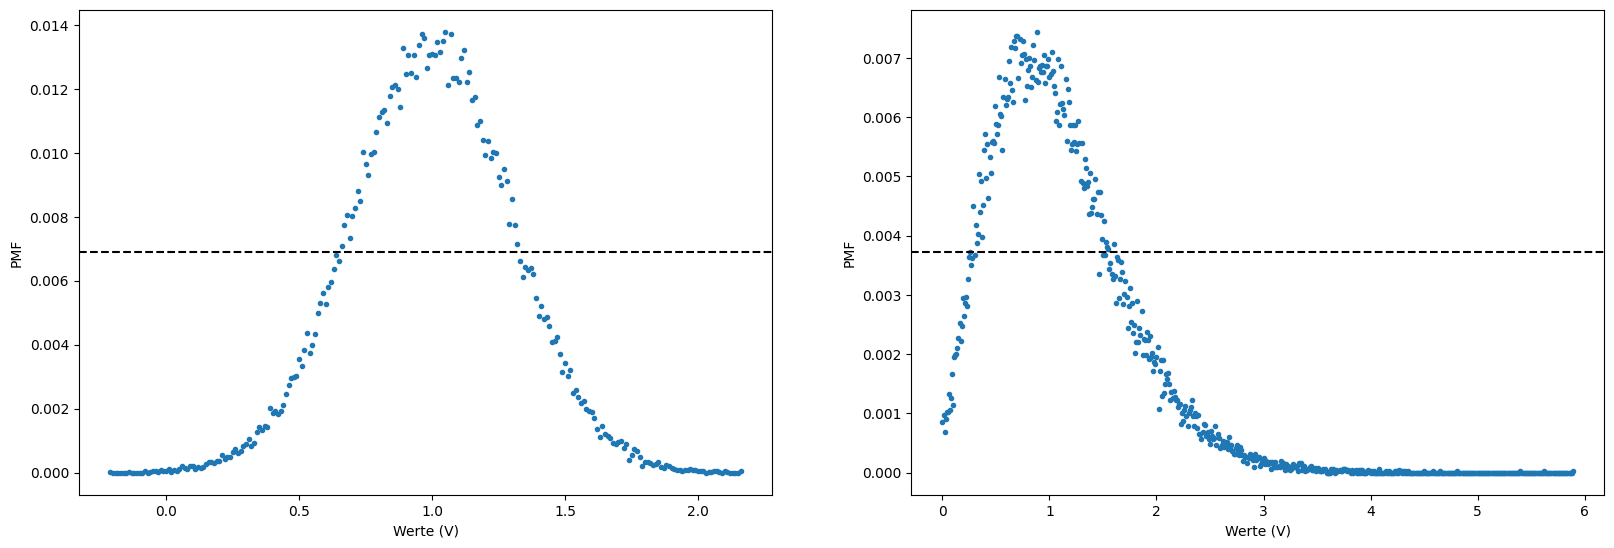

In [22]:
fig = plt.figure(figsize=(50*cm, 16*cm))

ax = fig.add_subplot(1, 2, 1)
x, px = PMF(v1, resolution)

fwhm = FWHM2(x, px)
sigma = np.sqrt(np.var(v1))

ax.plot(x, px, '.')
ax.axhline(np.max(px) / 2, color='k', linestyle='--')

ax.set_xlabel('Werte (V)')
ax.set_ylabel('PMF')

print('Erster Datensatz:')
print('FWHM: {:f}'.format(fwhm))
print('sigma: {:f} -> FWHM = {:f}'.format(sigma, 2*np.sqrt(2*np.log(2))*sigma ) )


ax = fig.add_subplot(1, 2, 2)
x, px = PMF(v2, resolution)

fwhm = FWHM2(x, px)
sigma = np.sqrt(np.var(v2))

ax.plot(x, px, '.')
ax.axhline(np.max(px)/2, color='k', linestyle='--')

ax.set_xlabel('Werte (V)')
ax.set_ylabel('PMF')

print('Zweiter Datensatz:')
print('FWHM: {:f}'.format(fwhm))
print('sigma: {:f} -> FWHM = {:f}'.format(sigma, 2*np.sqrt(2*np.log(2))*sigma ) ) 

#  Aufgabe 2 Momente

Momente sind charakteristische Grössen für Zufallsvariablen und sind verknüpft mit Erwartungswert, Varianz, Schiefe etc. In der Vorlesung haben Sie die Formel für das n-te Moment von diskrete Zufallsvariablen gesehen:

$$m_n = \sum_{i=0}^{N}x^n_ip_i,$$

wobei der Wert $x_i$ mit Wahrscheinlichkeit $p_i$ im Datensatz vorkommt. Da $p_i = \frac{n_i}{M}$, wobei $M$ die Länge des Datenarrays und $n_i$ die Anzahl Datenpunkte $X_j$ mit Wert $x_i$ im Datenarray ist, kann man das n-te Moment auch via:

$$ m_n =\frac{1}{M}\sum_{j=0}^{M}X_j^n $$
berechnen. Dies hat den Vorteil, dass man nicht auf ein Binning angewiesen ist.

### a)

Schreiben Sie eine Funktion, die das n-te Moment aus einem Datensatz berechnet.

In [24]:
def moment(data, n):
    return np.sum(data**n) / len(data)

### b)

Die ersten beiden Momente hängen mit dem Mittelwert und der Varianz zusammen. Berechnen Sie für die beiden Datensätze Mittelwert und Varianz einmal über die Momente und einmal mit Numpy und vergleichen Sie die Werte.

In [25]:
m1 = moment(v1, 1)
mu1 = moment(v1 - m1, 2)
print('Mittelwert aus den Momenten:    {:0.3f}    und mit Numpy:    {:0.3f}'.format(m1, np.mean(v1)))
print('Varianz aus den Momenten:       {:0.3f}    und mit Numpy:    {:0.3f}'.format(mu1, np.var(v1)))

m2 = moment(v2, 1)
mu2 = moment(v2 - m2, 2)
print('Mittelwert aus den Momenten:    {:0.3f}    und mit Numpy:    {:0.3f}'.format(m2, np.mean(v2)))
print('Varianz aus den Momenten:       {:0.3f}    und mit Numpy:    {:0.3f}'.format(mu2, np.var(v2)))


Mittelwert aus den Momenten:    0.998    und mit Numpy:    0.998
Varianz aus den Momenten:       0.090    und mit Numpy:    0.090
Mittelwert aus den Momenten:    1.084    und mit Numpy:    1.084
Varianz aus den Momenten:       0.374    und mit Numpy:    0.374


### c)

Die höheren Momente geben zusätzliche Informationen über die Symmetrie und die Breite der Verteilung. Berechnen und vergleichen Sie die ersten drei zentralen Momente für die beiden Datensätze.

In [28]:
m1_1 = moment(v1, 1)
m1_2 = moment(v2, 1)
for i in range(3):
    n = i + 1
    mi_1 = moment(v1 - m1_1, n)
    mi_2 = moment(v2 - m1_2, n)
    print('{:n}-tes zentrales Moment vom ersten Datensatz: {:0.3f}, vom zweiten Datensatz: {:0.3f}'.format(n, mi_1, mi_2))

1-tes zentrales Moment vom ersten Datensatz: 0.000, vom zweiten Datensatz: -0.000
2-tes zentrales Moment vom ersten Datensatz: 0.090, vom zweiten Datensatz: 0.374
3-tes zentrales Moment vom ersten Datensatz: 0.000, vom zweiten Datensatz: 0.202
